## `TP Deep Clustering` 

L'objectif de ce TP consiste à créer un modèle constitué de plusieurs parties :

- Un auto-codeur, pré-entraîné pour apprendre la représentation condensée initiale des jeux de données non étiquetés.
- Une couche de clustering empilée sur l'encodeur pour affecter la sortie de l'encodeur à un cluster. Les poids de la couche de clustering sont initialisés avec les centres de cluster de K-Means basés sur l'évaluation actuelle.
- Entraîner le modèle de clustering pour affiner la couche de clustering et le codeur conjointement.


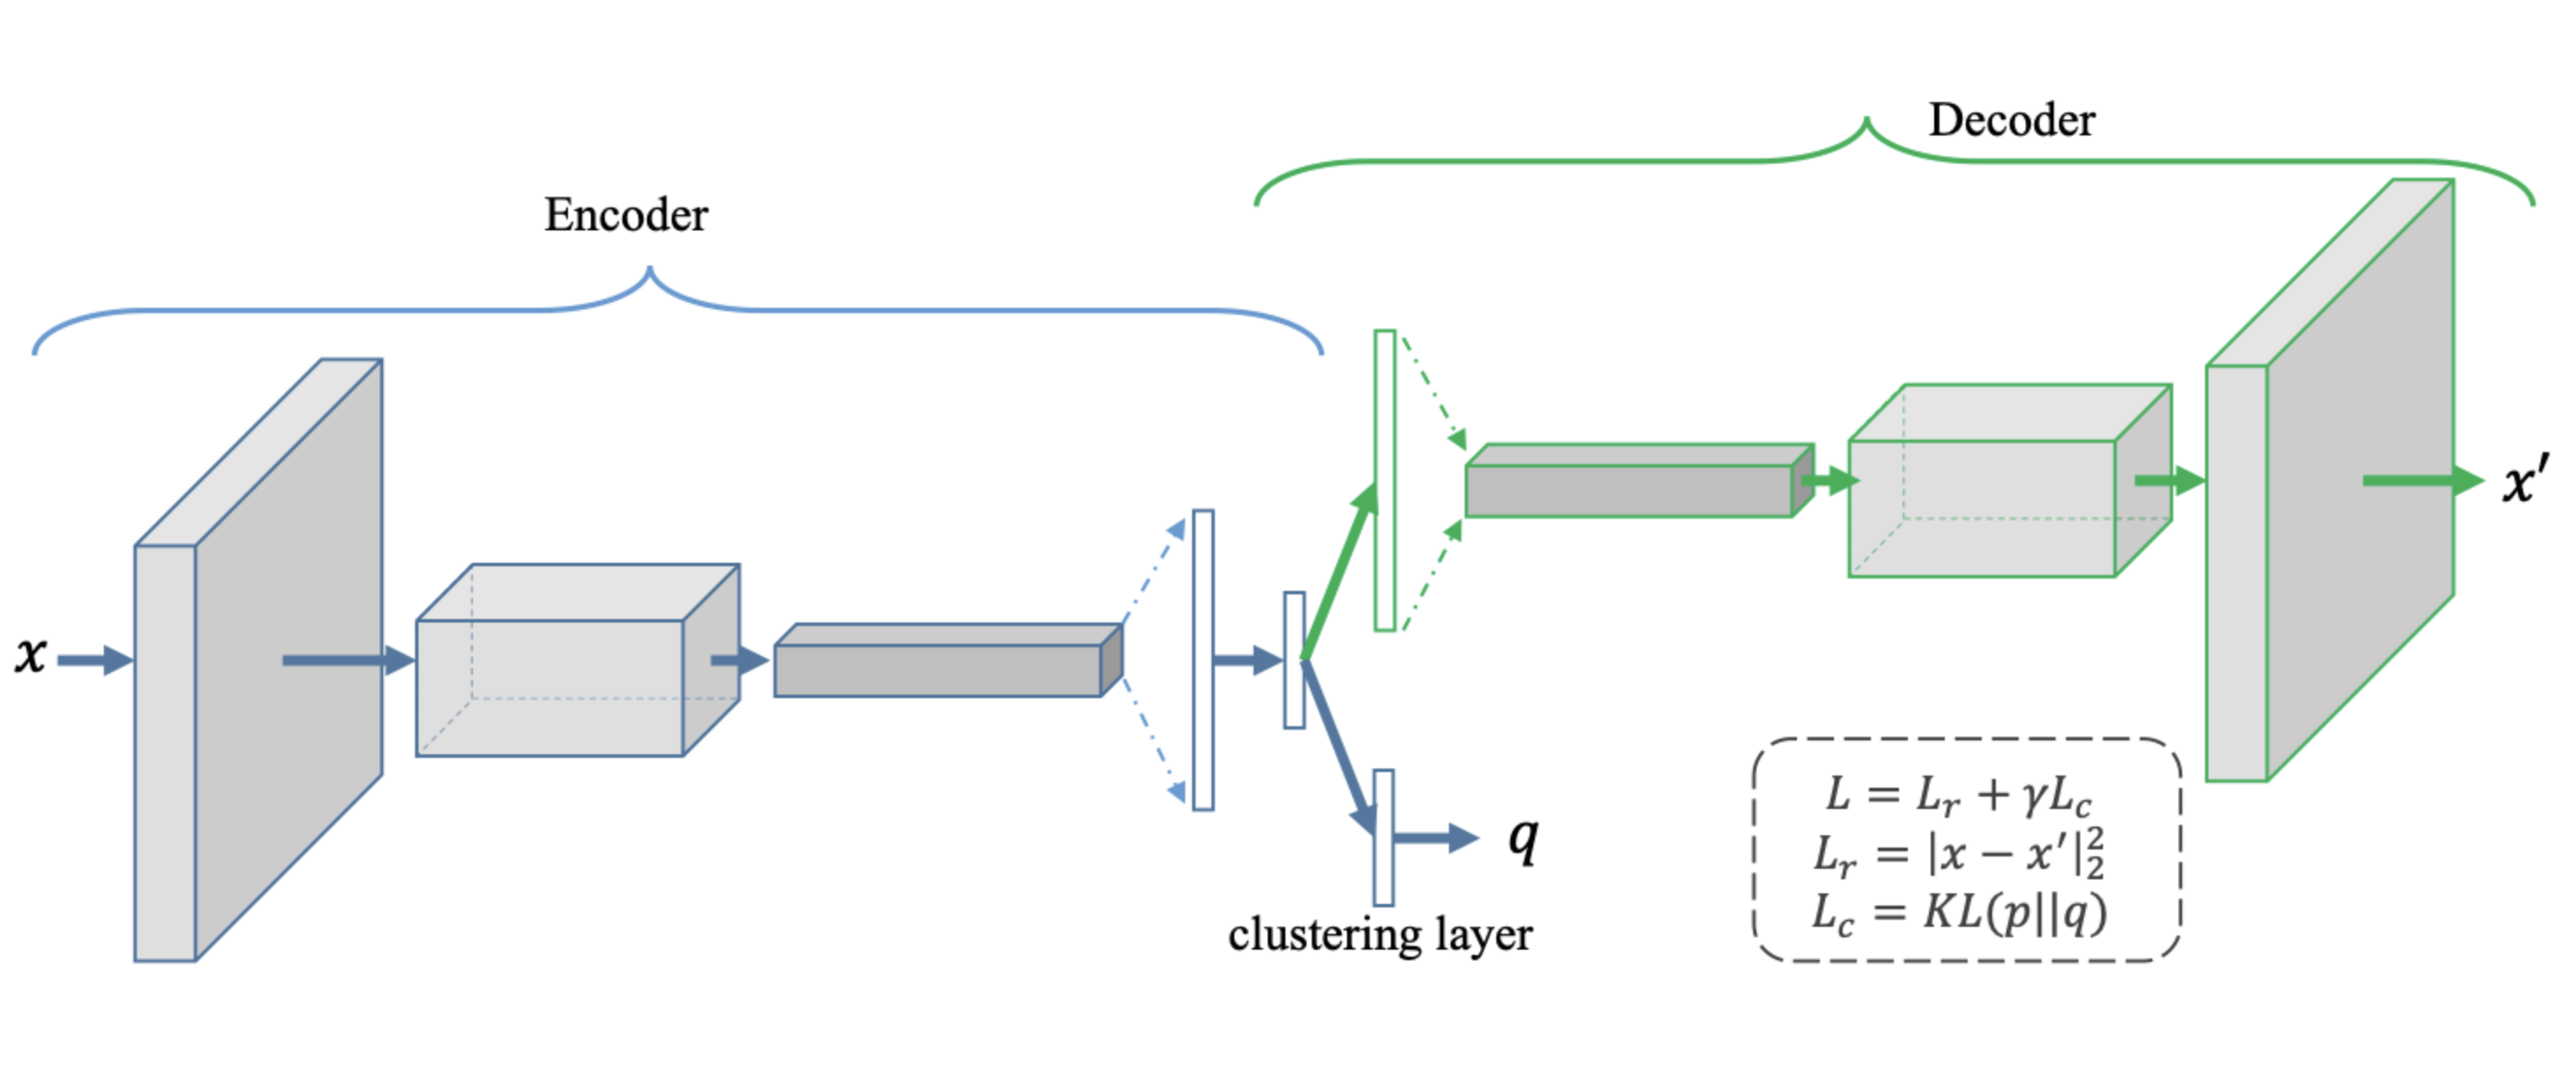

In [1]:
from IPython.display import Image, display
display(Image("/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_APPAUT/2026_TP2_DeepClustering/images/DeepClustering.png",width=700))

`L’encoder + k‑means en non supervisé :`
 - Pipeline non supervisé encoder + k‑means
 - Pré‑entraînement non supervisé de l’encoder

`Autoencoder conv :` 
 - apprend à reconstruire l’image, donc l’espace latent z se structure sans labels.
 - Ou méthode type DEC / Deep Embedded K‑Means où l’encoder est entraîné avec une loss qui dépend des clusters eux‑mêmes (distribution cible, KL, etc.).

`Clustering dans l'espace latent`
 - on passe les images dans l’encoder, 
 - récupères les embeddings $z_i$, 
 - on appliques k‑means sur les ${z_i}$.

`Les indices de clusters de k‑means sont tes pseudo‑labels non supervisés`.
- Option raffinement (deep embedded clustering)
 - On ré‑entraînes l’encoder en forçant les embeddings à se rapprocher des centres de leurs clusters (loss basée sur la KL entre assignations et une distribution cible plus « piquée »).

Les seules « étiquettes » sont produites par k‑means à partir des features apprises, pas par un annotateur humain.

In [2]:
from time import time
import numpy as np
import keras.backend as K # type: ignore
import tensorflow as tf
from tensorflow.keras.layers import Layer, InputSpec, UpSampling2D, Flatten, Reshape, Conv2DTranspose  # type: ignore
from tensorflow.keras.models import Model  # type: ignore
from tensorflow.keras.initializers import VarianceScaling  # type: ignore
from sklearn.cluster import KMeans
from sklearn.cluster import MiniBatchKMeans
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn import metrics
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

### `Chargement des données`

In [3]:
from keras.datasets import mnist  # type: ignore
from keras.datasets import fashion_mnist  # type: ignore à tester, + complexe que l'ensemble mnist 

import numpy as np

# Chargement et normalisation (entre 0 et 1) des données de la base de données MNIST/Fashion mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(f"x_train.shape : {x_train.shape}")
x_trainIm = x_train.astype('float32') / 255.
x_testIm = x_test.astype('float32') / 255.

print(f"x_trainIm.shape : {x_trainIm.shape}")
x_train_rshp = np.reshape(x_trainIm, (len(x_trainIm), 784))
x_test_rshp = np.reshape(x_testIm, (len(x_testIm), 784))

print(f"x_train_rshp.shape : {x_train_rshp.shape}")

x_train.shape : (60000, 28, 28)
x_trainIm.shape : (60000, 28, 28)
x_train_rshp.shape : (60000, 784)


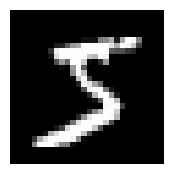

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(2,2))
plt.imshow(x_train[0], cmap='gray')
plt.axis('off')
plt.show()

### `Baseline par clustering classique par kmeans`

`y_pred_kmeans` 
- vecteur d’entiers de taille (n_samples,) 
- contient l’indice du cluster auquel KMeans a affecté chaque sample (0, 1, ..., n_clusters-1)
- il n’y a pas de correspondance directe entre indice de cluster et indice de classe. 
- les indices de KMeans sont arbitraires

In [5]:
# Nombre de classes à trouver
n_clusters=10
# nombre de chiffres
n_digits = len(np.unique(y_test))
print(f"n_digits : {n_digits}")
# Initialisation du Kmeans 
kmeans = MiniBatchKMeans(n_clusters = n_digits)

# Appliquer Kmeans sur base d'apprentissage
y_pred_kmeans = kmeans.fit_predict(x_train_rshp)
print(f"y_pred_kmeans.shape : {y_pred_kmeans.shape}")
print(f"y_pred_kmeans : {y_pred_kmeans}")

n_digits : 10
y_pred_kmeans.shape : (60000,)
y_pred_kmeans : [7 6 1 ... 7 4 0]


`Ecrire acc = accuracy_score(y_pred_kmeans, y_train) n’a pas de sens.`

Les options cohérentes sont donc :
 - remapping cluster → classe (via matrice de confusion + Hungarian) puis calculer l’accuracy;
 - utiliser des métriques de clustering (Adjusted Rand Index, NMI, etc.) plutôt qu’une accuracy.

In [6]:
# Score de performance
acc = accuracy_score(y_train,y_pred_kmeans)
print(f"Accuracy KMeans (fit_predict) : {acc:.4f}")

Accuracy KMeans (fit_predict) : 0.0486


### `Attribution des étiquettes de cluster`

 - La classification K-means est une méthode d'apprentissage automatique non supervisée
 - Les étiquettes KMeans référence la classification attribué à chaque élément et non à l'entier cible réel
 - Les fonctions ci-dessous permettent de prédir à quel classe correspond à chaque cluster

__`Ce que signifie cet appel`__
 - y_pred_kmeans (ou kmeans.labels_) sont les labels de clusters produits par KMeans.
 - y_train sont les vraies étiquettes (supervisées) de tes données d’entraînement.
 - `retrieve_info(cluster_labels, y_train)`
   - calcule, pour chaque cluster, la classe majoritaire dans ce cluster 
   - renvoie un tableau reference_labels qui fait la correspondance
   - reference_labels[i] = classe majoritaire parmi les points du cluster i.

In [7]:
def retrieve_info(cluster_labels, y_train):
    cluster_labels = np.asarray(cluster_labels).ravel()
    y_train = np.asarray(y_train).ravel()
    n_clusters = len(np.unique(cluster_labels))
    reference_labels = np.zeros(n_clusters, dtype=int)   # <-- 1D
    #print(f"cluster_labels : {cluster_labels.shape}")
    for i in range(n_clusters):
        index = (cluster_labels == i)
        num = np.bincount(y_train[index]).argmax()
        reference_labels[i] = num
    #print(f"index.shape : {index.shape}")    
    return reference_labels

- `La fonction correspondance effectue le mapping numéro de cluster classe réel`
- `Pour chaque prédiction cluster associé à un élement, la classe correspondante`

In [8]:
def correspondance(y_pred_kmeans,y_train):
  # y_pred_kmeans (ou kmeans.labels_) sont les labels de clusters produits par KMeans, 
  # reference_labels[i] = classe majoritaire parmi les points du cluster i.
  reference_labels = retrieve_info(y_pred_kmeans,y_train)
  number_labels = np.zeros(len(y_pred_kmeans))
  for i in range(len(y_pred_kmeans)):
    number_labels[i] = reference_labels[y_pred_kmeans[i]]
  return number_labels

`Obtenir un score de performance`
- Après la correspondance clusters → classes, 
- Utiliser _reference_labels_ pour transformer les labels de clusters en labels de classes, 
- puis calculer une accuracy classique.

In [9]:
# labels prédits (après correspondance cluster -> classe)
y_train_pred = correspondance(y_pred_kmeans, y_train)
print(f"y_train_pred.shape : {y_train_pred.shape}")

# score de performance sur l'apprentissage
score = accuracy_score(y_train, y_train_pred)
print(f"Accuracy KMeans (apprentissage) : {score:.4f}")

y_train_pred.shape : (60000,)
Accuracy KMeans (apprentissage) : 0.5215


In [ ]:
# Affichage des données 
count=60000
ListeData = np.random.choice(len(y_train_pred), count)
inputs = x_train_rshp[ListeData]
classes = y_train[ListeData]
embedTSNE = TSNE(n_components=2).fit_transform(inputs)

In [ ]:
import matplotlib.pyplot as plt

def display_2Dreduce(classes,embedTSNE=[] ,embedPCA=[], mode=("TSNE", "PCA")):
    """
    mode peut contenir :
      - ("TSNE", "PCA")  -> les deux graphiques côte à côte
      - ("TSNE",)        -> uniquement t-SNE
      - ("PCA",)         -> uniquement PCA
    """
    color = classes.astype(int)

    show_tsne = "TSNE" in mode
    show_pca  = "PCA" in mode

    if show_tsne and show_pca:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        ax = axes[0]
        sc = ax.scatter(embedTSNE[:, 0], embedTSNE[:, 1],
                        c=color, cmap="Spectral", s=5, alpha=0.8)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title("MNIST en 2D par t-SNE", fontsize=8)
        fig.colorbar(sc, ax=ax)

        ax = axes[1]
        sc = ax.scatter(embedPCA[:, 0], embedPCA[:, 1],
                        c=color, cmap="Spectral", s=5, alpha=0.8)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title("MNIST en 2D par PCA", fontsize=8)
        fig.colorbar(sc, ax=ax)

        plt.tight_layout()
        plt.show()

    elif show_tsne:
        fig, ax = plt.subplots(figsize=(6, 5))
        sc = ax.scatter(embedTSNE[:, 0], embedTSNE[:, 1],
                        c=color, cmap="Spectral", s=5, alpha=0.8)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title("MNIST en 2D par t-SNE", fontsize=8)
        plt.colorbar(sc)
        plt.show()

    elif show_pca:
        fig, ax = plt.subplots(figsize=(6, 5))
        sc = ax.scatter(embedPCA[:, 0], embedPCA[:, 1],
                        c=color, cmap="Spectral", s=5, alpha=0.8)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title("MNIST en 2D par PCA", fontsize=8)
        plt.colorbar(sc)
        plt.show()


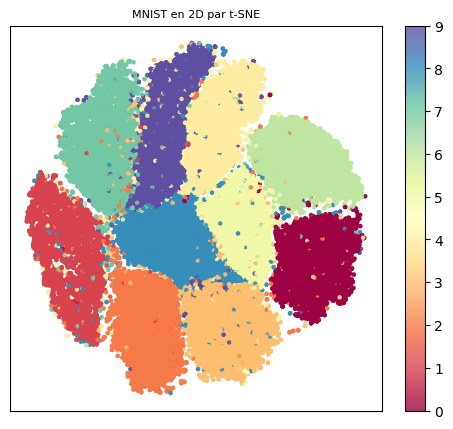

In [ ]:
display_2Dreduce(classes,embedTSNE=embedTSNE, mode=("TSNE"))

### `Autoencodeur classique à définir`

In [ ]:
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.layers import Dense, Input #type: ignore

# Autoencodeur simple pour MNIST (28x28 -> 784)
autoencoder = Sequential([
    Input(shape=(784,)),          # image 28x28 aplatie
    Dense(128, activation="relu"),
    Dense(64, activation="relu"), # couche "bottleneck"
    Dense(128, activation="relu"),
    Dense(784, activation="sigmoid")  # reconstruction 784, même taille que l'entrée
])

2026-02-20 14:15:28.382458: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Max
2026-02-20 14:15:28.382485: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-02-20 14:15:28.382493: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
2026-02-20 14:15:28.382528: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-02-20 14:15:28.382539: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [ ]:
autoencoder.compile(
    optimizer="adam",
    loss="mse",   
    metrics=["accuracy"],
)

### `Entraînement de l'autoencodeur` 

In [ ]:
# Entraînement de l'autoencodeur 
history = autoencoder.fit(x_train_rshp, x_train_rshp,
                epochs=25,
                batch_size=128,
                shuffle=True,
                validation_data=(x_test_rshp, x_test_rshp))

Epoch 1/25


2026-02-20 14:15:29.059436: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.0093 - loss: 0.0702 - val_accuracy: 0.0115 - val_loss: 0.0199
Epoch 2/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.0104 - loss: 0.0179 - val_accuracy: 0.0114 - val_loss: 0.0134
Epoch 3/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.0109 - loss: 0.0131 - val_accuracy: 0.0124 - val_loss: 0.0112
Epoch 4/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.0114 - loss: 0.0111 - val_accuracy: 0.0116 - val_loss: 0.0098
Epoch 5/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.0127 - loss: 0.0097 - val_accuracy: 0.0133 - val_loss: 0.0086
Epoch 6/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.0132 - loss: 0.0088 - val_accuracy: 0.0127 - val_loss: 0.0079
Epoch 7/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.0126 - loss: 0.0081 - val_accuracy: 0.0114 - val_loss: 0.0074
Epoch 8/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.0132 - loss: 0.0075 - val_accuracy: 0.011

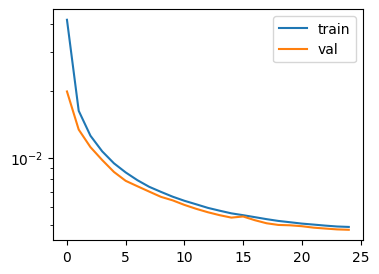

In [ ]:
fig, ax = plt.subplots(figsize=(4, 3))
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.legend(); plt.yscale("log")

In [ ]:
autoencoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 654,578 (2.50 MB)

 Trainable params: 218,192 (852.31 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 436,386 (1.66 MB)

In [ ]:
# Encoder et décoder quelques chiffres de l'ensemble test
from tensorflow.keras import Model, Input # type: ignore
# encoder = entrée -> couche bottleneck
_ = autoencoder(x_train_rshp[:1]) 

# 2) Récupérer l'input via la première couche
inp = Input(shape=(784,))
x = autoencoder.layers[0](inp)  # Dense(128)
code = autoencoder.layers[1](x)  # Dense(64)
encoder = Model(inp, code)

# decoder : code latent -> reconstruction
latent_input = Input(shape=(64,))
x = autoencoder.layers[2](latent_input)   # Dense(128)
decoded_output = autoencoder.layers[3](x) # Dense(784)
decoder = Model(latent_input, decoded_output)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


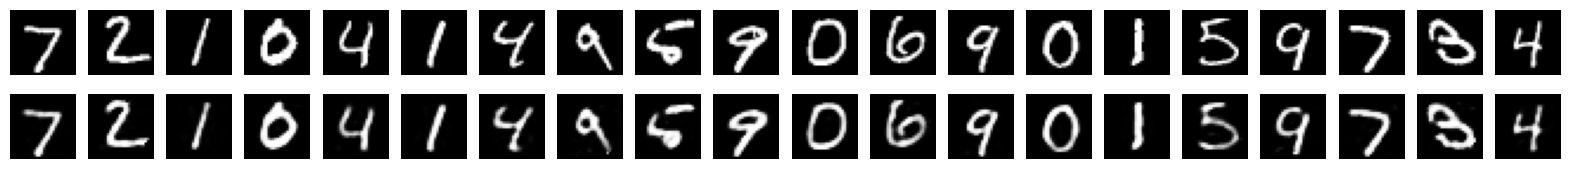

In [ ]:
n = 20  # Combien de chiffres nous allons afficher
# Afficher l'image reconstruite à partir de l'espace latent après entraînement
# encoder / decoder
encoded_imgs = encoder.predict(x_test_rshp[:n])
decoded_imgs = decoder.predict(encoded_imgs)

import matplotlib.pyplot as plt

plt.figure(figsize=(20, 2))
for i in range(n):
    # original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_rshp[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # reconstruit
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
plt.show()

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
encoded_imgs.shape : (60000, 64)


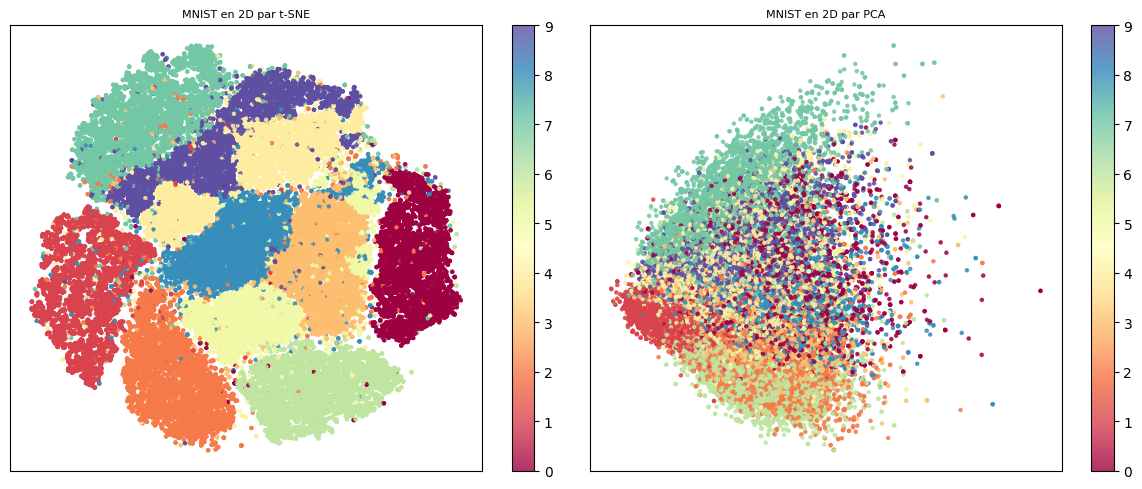

In [ ]:
# Affichage de l'espace latent par réduction de dimension 
count=2000
inputs = x_train[ListeData]
x_trainIm = inputs.astype('float32') / 255
x_train_rshp = np.reshape(x_trainIm, (len(x_trainIm), 784))
classes = y_train[ListeData]
# Récupération des données dans l'espace latent
encoded_imgs = encoder.predict(x_train_rshp)
print(f"encoded_imgs.shape : {encoded_imgs.shape}")
# 1) Réduction de dimension 2D par ACP et affichage
embedPCA = PCA(n_components=2).fit_transform(encoded_imgs)
# 2) Réduction de dimension 2D avec t-SNE
embedTSNE = TSNE(n_components=2).fit_transform(encoded_imgs)
# Affichage de l'espace latent par réduction de dimension ACP vs t-SNE
display_2Dreduce(classes,embedTSNE ,embedPCA, mode=("TSNE", "PCA"))

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Performance de l'autoencodeur : accuracy sur kmeans sur l'espace latent : : 0.5559


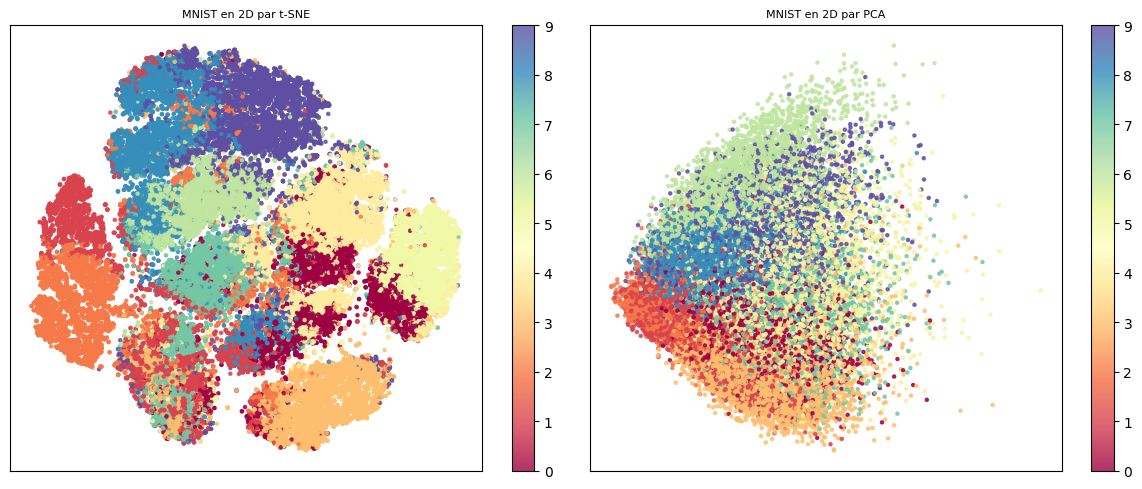

In [ ]:
# Classification par kmeans de l'espace latent sur l'ensemble d'apprentissage
inputsTrain = x_train.astype('float32') / 255
inputsTrain_rshp = np.reshape(inputsTrain, (len(inputsTrain), 784))
classesTrain = y_train
# Récupération des données dans l'espace latent
encoded_allimgs = encoder.predict(inputsTrain_rshp)
# Initialisation du Kmeans 
kmeans = MiniBatchKMeans(n_clusters = n_digits)
# Appliquer Kmeans sur base d'apprentissage
y_pred_kmeans = kmeans.fit_predict(inputsTrain_rshp)
# labels prédits (après correspondance cluster -> classe)
y_train_pred = correspondance(y_pred_kmeans, y_train)
# Score de performance sur l'apprentissage
acc = accuracy_score(y_train_pred, classesTrain)
print(f"Performance de l'autoencodeur : accuracy sur kmeans sur l'espace latent : : {acc:.4f}")
# 2) Réduction de dimension 2D avec PCA
embedPCA = PCA(n_components=2).fit_transform(encoded_allimgs)
# 2) Réduction de dimension 2D avec t-SNE
embedTSNE = TSNE(n_components=2).fit_transform(encoded_allimgs)
# Affichage de l'espace latent par réduction de dimension ACP vs t-SNE
display_2Dreduce(y_pred_kmeans,embedTSNE ,embedPCA, mode=("TSNE", "PCA"))

### `Couche de Clustering` 
:::
`Deep Convolutional Embedded Clustering (DCEC), est une variante de DEC`.
 - Elle ajoute une couche de clustering au-dessus d’un autoencodeur convolutionnel, 
 - Elle précise les formules de $\textcolor{red}{q_{ij}}$, de la loss de clustering de la distribution cible $\textcolor{red}{p_{ij}}$.

`Couche de clustering et soft labels` $\large \textcolor{red}{q_{ij}}$
- Un encodeur $\large \textcolor{red}{f_θ}$ projette chaque image $\large \textcolor{red}{x_i}$ dans un espace latent $\large \textcolor{red}{z_i=f_θ(x_i)}$
 - La couche de clustering maintient des centres de clusters $\textcolor{red}{μ_j}$ (paramètres entraînables).
 - Pour chaque point latent $\textcolor{red}{z_i}$ et chaque centre $\textcolor{red}{μ_j}$, on calcule un soft label $\textcolor{red}{q_{ij}}$ via une distribution t de Student :

:::
:::
`Couche de Clustering Deep Embedded Clustering (DEC)`
`1.` Elle prend un vecteur de caractéristiques (la sortie de l'encodeur) 
`2.` Le transforme en probabilités d’appartenance aux clusters via une `distribution t de Student`.
`3.` La couche de clustering maintient les centres de cluster $\textcolor{red}{µ_j}$ comme poids entraînables 
`4.` Elle projette chaque point intégré $\textcolor{red}{z_i}$ en soft label $\textcolor{red}{q_i}$ par la distribution $t$ de Student 
`5.` Elle est utilisée comme noyau pour mesurer la similarité entre $\textcolor{red}{zi = fθ(x_i)}$ et le centroïd $\textcolor{red}{µ_j}$ :

$$\textcolor{red}{q_{ij}=\frac{(1+\|z_i-\mu_j\|^2)^{-1}}{\sum_j(1+\|z_i-\mu_j\|^2)^{-1}}}$$

 - $\textcolor{red}{q_{ij}}$ est la $\textcolor{red}{j^{ième}}$ entrée du vecteur $\textcolor{red}{q_i}$, représentant la probabilité d'appartenance de $\textcolor{red}{z_i}$ au cluster $\textcolor{red}{j}$
 - La normalisation au dénominateur fait que $\textcolor{red}{\sum_j q_{ij} = 1}$ pour chaque $\textcolor{red}{i}$
 $\textcolor{red}{\text{C’est exactement ce que fait la fonction ClusteringLayer ci-dessous }}$: 
- distances au carré, noyau __t__ de Student, puis normalisation par ligne.
 :::
 :::
 `La « t de Student »` 
  - Une distribution c'est une de probabilité, 
  - Elle est utilisée comme noyau pour mesurer la similarité entre un point latent $\textcolor{red}{x_i}$ et un centroïde $\textcolor{red}{u_j}$,
  - Exactement comme dans t‑SNE et DEC.
 $$\textcolor{red}{q_{ij} \propto \left( 1 + \frac{\lVert x_i - u_j \rVert^{2}}{\alpha} \right)^{\large -\frac{\alpha + 1}{2}}}$$
 - Puis on normalise sur $\textcolor{red}{j}$ pour obtenir une distribution de probabilité sur les clusters (soft labels)
 - Contrairement à KMeans classique (hard labels), on obtient des assignations molles (soft assignments). 
 - Comme cette couche est différentiable et intégrée au réseau, on peut apprendre conjointement :
   - la représentation latente (l’encodeur),
   - les centres de clusters (self.clusters), en minimisant par exemple une Kullback–Leibler 
   - Cette `KL` s'effectue entre la distribution $\textcolor{red}{q}$ et la distribution cible $\textcolor{red}{p}$ (c’est DEC).
:::
:::
`KL, c’est la divergence de Kullback–Leibler souvent notée` $\textcolor{red}{D_{KL}}$ 
$$\textcolor{red}{D_{\text{KL}}(P \parallel Q)= \sum_{x \in X} P(x)\,\log \frac{P(x)}{Q(x)}}$$
 - Quantifie à quel point une distribution de probabilité $\textcolor{red}{Q}$ est différente d’une distribution «vraie» $\textcolor{red}{P}$
 - Considérons : 
    - $\textcolor{red}{P}$ soit la « vraie » loi des données 
    - $\textcolor{red}{Q}$ une approximation (modèle)
$\textcolor{red}{D_{KL}(P||Q)}$ mesure la perte d’information moyenne, si on encodait les données telles que : 
 - elles suivaient $\textcolor{red}{Q}$ alors qu’elles suivent en réalité $\textcolor{red}{P}$
 - si $\textcolor{red}{P = Q}$, la divergence est 0 (pas de perte).
 - plus $Q$ est différent de $\textcolor{red}{P}$ plus le $\textcolor{red}{KL}$ est grand.

__Perte de clustering $L_c$ = divergence KL entre P et Q__
 - On note $Q=(q_{ij})$ la distribution de soft labels produite par la couche de clustering.
 - On définit une distribution cible $P=(p_{ij})$
 - La loss de clustering est une divergence de Kullback–Leibler :
 $$\textcolor{red}{L_c = KL(P \parallel Q)= \sum_i \sum_j p_{ij} \log \frac{p_{ij}}{q_{ij}}}$$

 Avec les autoencodeurs / clustering profonds (comme DEC), on minimise souvent une KL entre une distribution cible P (par ex. labels « affinés ») et la distribution de clusters produite par le modèle Q
:::


:::
 - La couche de classification convertit l'échantillon d'entrée (caractéristique) en une étiquette souple
 - C'est-à-dire un vecteur qui représente la probabilité d'appartenance de l'échantillon à chaque groupe
 - Probabilité d'appartenance de l'échantillon à chaque cluster.
 - La probabilité est calculée avec la distribution t de student.        
    - `model.add(ClusteringLayer(n_clusters=10))`
      - __n_clusters__ : nombre de clusters.
      - __weights__ : liste de tableaux Numpy de forme (n_clusters, n_features) qui représente les centres de clusters initiaux.
      - __alpha__ : paramètre de la distribution t de Student. La valeur par défaut est 1.0.

`Forme de l'entrée` : Tenseur 2D avec la forme : __(n_samples, n_features)__
`Forme en sortie` : Tenseur 2D avec forme : __(n_samples, n_clusters)__
:::

In [ ]:
from IPython.display import Image, display
display(Image("M2_IAFA/TP_M2IAFA/TP_M2_APPAUT/2026_TP2_DeepClustering/images/otoncdrKmnsClstrg.jpg",width=400))

In [ ]:
class ClusteringLayer(Layer):

    def __init__(self, n_clusters, weights=None, alpha=1.0, **kwargs):
        if 'input_shape' not in kwargs and 'input_dim' in kwargs:
            kwargs['input_shape'] = (kwargs.pop('input_dim'),)
        super(ClusteringLayer, self).__init__(**kwargs)
        self.n_clusters = n_clusters
        self.alpha = alpha
        self.initial_weights = weights
        self.input_spec = InputSpec(ndim=2)

    def build(self, input_shape):
        assert len(input_shape) == 2
        input_dim = input_shape[1]
        self.input_spec = InputSpec(dtype=K.floatx(), shape=(None, input_dim))
        self.clusters = self.add_weight(shape=(self.n_clusters, input_dim), initializer='glorot_uniform', name='clusters')
        if self.initial_weights is not None:
            self.set_weights(self.initial_weights)
            del self.initial_weights
        self.built = True

    # Distribution t de student, la même que celle utilisée dans l'algorithme t-SNE.
    # q_ij = 1/(1+dist(x_i, u_j)^2), puis normalisation.
    # Arguments : inputs : la variable contenant les données, shape=(n_samples, n_features)
    # Retourne  : q la distribution t de student, ou des étiquettes souples pour chaque échantillon. shape=(n_samples, n_clusters)
    def call(self, inputs, **kwargs):
      # distance au carré entre chaque point et chaque centroïde
      q = 1.0 / (1.0 + (K.sum(K.square(K.expand_dims(inputs, axis=1) - self.clusters), axis=2) / self.alpha))
      #  # noyau t de Student
      q **= (self.alpha + 1.0) / 2.0
      # # normalisation par ligne
      q = K.transpose(K.transpose(q) / K.sum(q, axis=1))
      # q a shape (n_samples, n_clusters) et chaque ligne est un vecteur de probabilités qui somme à 1
      return q

    def compute_output_shape(self, input_shape):
        assert input_shape and len(input_shape) == 2
        return input_shape[0], self.n_clusters

    def get_config(self):
        config = {'n_clusters': self.n_clusters}
        base_config = super(ClusteringLayer, self).get_config()
        return dict(list(base_config.items()) + list(config.items()))


:::
`Définition de la distribution P cible définie comme :` 
 - $\textcolor{red}{p_{ij}}$ est la $\textcolor{red}{j^{ième}}$ entrée de $\textcolor{red}{p_i}$ représentant la probabilité d'appartenance de la donnée $\textcolor{red}{i}$ la classe $\textcolor{red}{j}$
 - Dans DEC, la distribution cible  $\textcolor{red}{P=(p_{ij}})$ se calcule à partir de $\textcolor{red}{Q=(q_{ij}}$) (la sortie de ta ClusteringLayer) en renforçant les assignations confiantes.

`La formule standard est :` $\large \textcolor{red}{p_{ij}=\frac{q_{ij}^2/\sum_i q_{ij}}{\sum_j (q_{ij}^2/\sum_i q_{ij})}}$
:::

In [ ]:
# Calcul de la distribution cible
import tensorflow.keras.backend as K # type: ignore

def target_distribution_(q):
    # f_j = somme_i q_ij
    f = K.sum(q, axis=0)                       # (n_clusters,)
    weight = (q ** 2) / f                      # (n_samples, n_clusters)
    p = weight / K.sum(weight, axis=1, keepdims=True)
    return p


In [ ]:
import numpy as np

def target_distribution(q):
    weight = q ** 2 / q.sum(0)           # (n_samples, n_clusters)
    return (weight.T / weight.sum(1)).T  # normalisation ligne


### `Entrainement du modèle avec la couche de clustering`

In [ ]:
# paramètres à fixer
loss = 0
index = 0
maxiter =4000
update_interval = 140
batch_size=128
index_array = np.arange(x_train.shape[0])
tol = 0.005 # seuil pour critère d'arrêt

In [ ]:
inputs = x_train
x_trainIm = inputs.astype('float32') / 255
x_trainrshp = np.reshape(x_trainIm, (len(x_trainIm), 784))

x_train_rshp = tf.convert_to_tensor(x_train_rshp, dtype=tf.float32)
y_train = tf.convert_to_tensor(y_train, dtype=tf.int32)

In [ ]:
# 0) Initialisation de K-means
kmeans = KMeans(n_clusters=n_clusters, n_init=20)
# 1) K-means dans l’espace latent
y_pred= kmeans.fit_predict(encoder.predict(x_train_rshp))
y_pred_last = np.copy(y_pred)
# 2) Modèle DEC : encodeur + couche de clustering
clustering_layer = ClusteringLayer(n_clusters, name='clustering')(encoder.output)
model = Model(inputs=encoder.input, outputs=clustering_layer)
# 3) Initialiser la couche de clustering avec les μ_j latents
μj = kmeans.cluster_centers_ # array NumPy (n_clusters, n_features) 
model.get_layer(name='clustering').set_weights([μj])
# 4) Compiler pour optimiser la KL (DEC)
model.compile(optimizer="Adam", loss='kld')

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


In [ ]:
for ite in range(int(maxiter)):
    if ite % update_interval == 0:
        # projette chaque point intégré zi en soft label qi par la distribution $t$ de Student
        # calcule les soft labels qij pour tous les échantillons d’entraînement.
        q = model.predict(x_train_rshp, verbose=0)
        # p est la distribution cible définie comme
        p = target_distribution(q)  # mise à jour de la distribution cible p 

        # evaluation de la performance du clustering 
        # transforme les soft labels en labels de cluster « durs »
        # 1 indique l’axe sur lequel on prend le max, ici l’axe des colonnes
        y_pred = q.argmax(1)
        if y_train is not None: 
            # La fonction correspondance effectue le mapping numéro de cluster classe réel
            y_pred=correspondance(y_pred,y_train)
            acc = np.round(accuracy_score(y_train, y_pred), 5)
            loss = np.round(loss, 5)
            print('(Iter , acc)  ',(ite, acc), ' ; loss=', loss)

        # check stop criterion - model convergence
        delta_label = np.sum(y_pred != y_pred_last).astype(np.float32) / y_pred.shape[0]
        y_pred_last = np.copy(y_pred)
        if ite > 0 and delta_label < tol:
            print('delta_label ', delta_label, '< tol ', tol)
            print('Reached tolerance threshold. Stopping training.')
            break
    idx = index_array[index * batch_size: min((index+1) * batch_size, x_train_rshp.shape[0])]
    loss = model.train_on_batch(x=x_train_rshp[idx], y=p[idx])
    index = index + 1 if (index + 1) * batch_size <= x_train_rshp.shape[0] else 0

AttributeError: Exception encountered when calling ClusteringLayer.call().

[1mmodule 'keras.backend' has no attribute 'sum'[0m

Arguments received by ClusteringLayer.call():
  • inputs=tf.Tensor(shape=(32, 64), dtype=float32)
  • kwargs=<class 'inspect._empty'>

In [ ]:
# Affichage de l'impact de cette couche clustering 

inputs = x_test[ListeData]
classes = y_test[ListeData]

x_trainIm = inputs.astype('float32') / 255
x_train_rshp = np.reshape(x_trainIm, (len(x_trainIm), 784))

# TSNE sur espace latent avec kmeans
coordsAC_V2 = encoder.predict(x_train_rshp)
coordsTSNE_V2 = TSNE(n_components=2).fit_transform(coordsAC_V2.reshape(count, -1))

fig2= plt.figure(figsize=(30, 10))
ax2=plt.subplot(1,3,1)
ax2.set_title("TSNE sur MNIST")
plt.scatter(coordsTSNE_V2[:, 0], coordsTSNE_V2[:, 1], c=classes,cmap='Paired')
plt.colorbar()

ax2 = plt.subplot(1,3,2)
ax2.set_title("tSNE sur espace latent")
plt.scatter(coordsTSNE_V2[:, 0], coordsTSNE_V2[:, 1], c=classes,cmap='Paired')
plt.colorbar()

ax2 = plt.subplot(1,3,3)
ax2.set_title("tSNE après clustering sur espace latent")
plt.scatter(coordsTSNE_V2[:, 0], coordsTSNE_V2[:, 1], c=classes,cmap='Paired')
plt.colorbar()

# Passer à la version convolutive de l'autoencodeur

In [ ]:
from tensorflow.keras.models import Sequential # type: ignore 
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D  # type: ignore
 
autoencoder = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(32, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2), padding="same"),
    Conv2D(64, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2), padding="same"),
    Conv2D(64, (3, 3), activation="relu", padding="same"),
    UpSampling2D((2, 2)),
    Conv2D(32, (3, 3), activation="relu", padding="same"),
    UpSampling2D((2, 2)),
    Conv2D(1, (3, 3), activation="sigmoid", padding="same")  # sortie 28x28x1
])

In [ ]:
autoencoder.compile(
    optimizer="adam",
    loss="mse",   
    metrics=["accuracy"],
)
# Entraînement de l'autoencodeur 
history = autoencoder.fit(x_train_rshp, x_train_rshp,
                epochs=25,
                batch_size=128,
                shuffle=True,
                validation_data=(x_test_rshp, x_test_rshp))

# Encoder et décoder quelques chiffres de l'ensemble test
from tensorflow.keras import Model, Input # type: ignore
# encoder = entrée -> couche bottleneck
_ = autoencoder(x_train_rshp[:1]) 

# 2) Récupérer l'input via la première couche
inp = Input(shape=(28, 28, 1))
x = autoencoder.layers[0](inp)  # Dense(128)
code = autoencoder.layers[1](x)  # Dense(64)
encoder = Model(inp, code)

# decoder : code latent -> reconstruction
latent_input = Input(shape=(64,))
x = autoencoder.layers[2](latent_input)   # Dense(128)
decoded_output = autoencoder.layers[3](x) # Dense(784)
decoder = Model(latent_input, decoded_output)